# Vergleich: Gesichtsemotion


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr, f_oneway


In [3]:
DATA_DIR = Path('../../data')
INPUT_CSV = DATA_DIR / '04_analysis_results' / 'visual_features' / '10_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_face_emotion.csv'
print(f'Reading {INPUT_CSV}')
df = pd.read_csv(INPUT_CSV)

LABEL_MAP = {
    'LABEL_0': 'Angry',
    'LABEL_1': 'Disgust',
    'LABEL_2': 'Fear',
    'LABEL_3': 'Happy',
    'LABEL_4': 'Neutral',
    'LABEL_5': 'Sad',
    'LABEL_6': 'Surprise',
}

if 'emotion_major_beit_readable' not in df.columns:
    if 'emotion_major_beit' in df.columns:
        df['emotion_major_beit_readable'] = df['emotion_major_beit'].map(lambda x: LABEL_MAP.get(x, x))
    else:
        df['emotion_major_beit_readable'] = 'Unbestimmt'


print(df[['influencer_type', 'emotion_major_beit_confidence', 'emotion_unique_labels']].groupby('influencer_type').agg(['count', 'mean', 'std']))


Reading ../../data/04_analysis_results/visual_features/10_AI_AND_REAL_TIKTOK_VIDEOS_stratified_with_face_emotion.csv                emotion_major_beit_confidence                      \                                        count      mean       std   influencer_type                                                     ai                                        250  0.572651  0.132848   real                                      250  0.597142  0.131054                   emotion_unique_labels                                                   count   mean       std  influencer_type                                         ai                                250  2.748  1.348990  real                              250  3.504  1.618785  

In [4]:
FRAME_ROOT = DATA_DIR / '02_media/stratified_sample/frames'

def get_video_id(row):
    return str(row.get('id') or row.get('video_id'))

def first_frame_path(video_id: str):
    folder = FRAME_ROOT / video_id
    if not folder.is_dir():
        return None
    frames = sorted(folder.glob('*.jpeg'))
    if not frames:
        frames = sorted(folder.glob('*.jpg'))
    if not frames:
        return None
    return frames[len(frames) // 2]

def load_image(path):
    import cv2
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


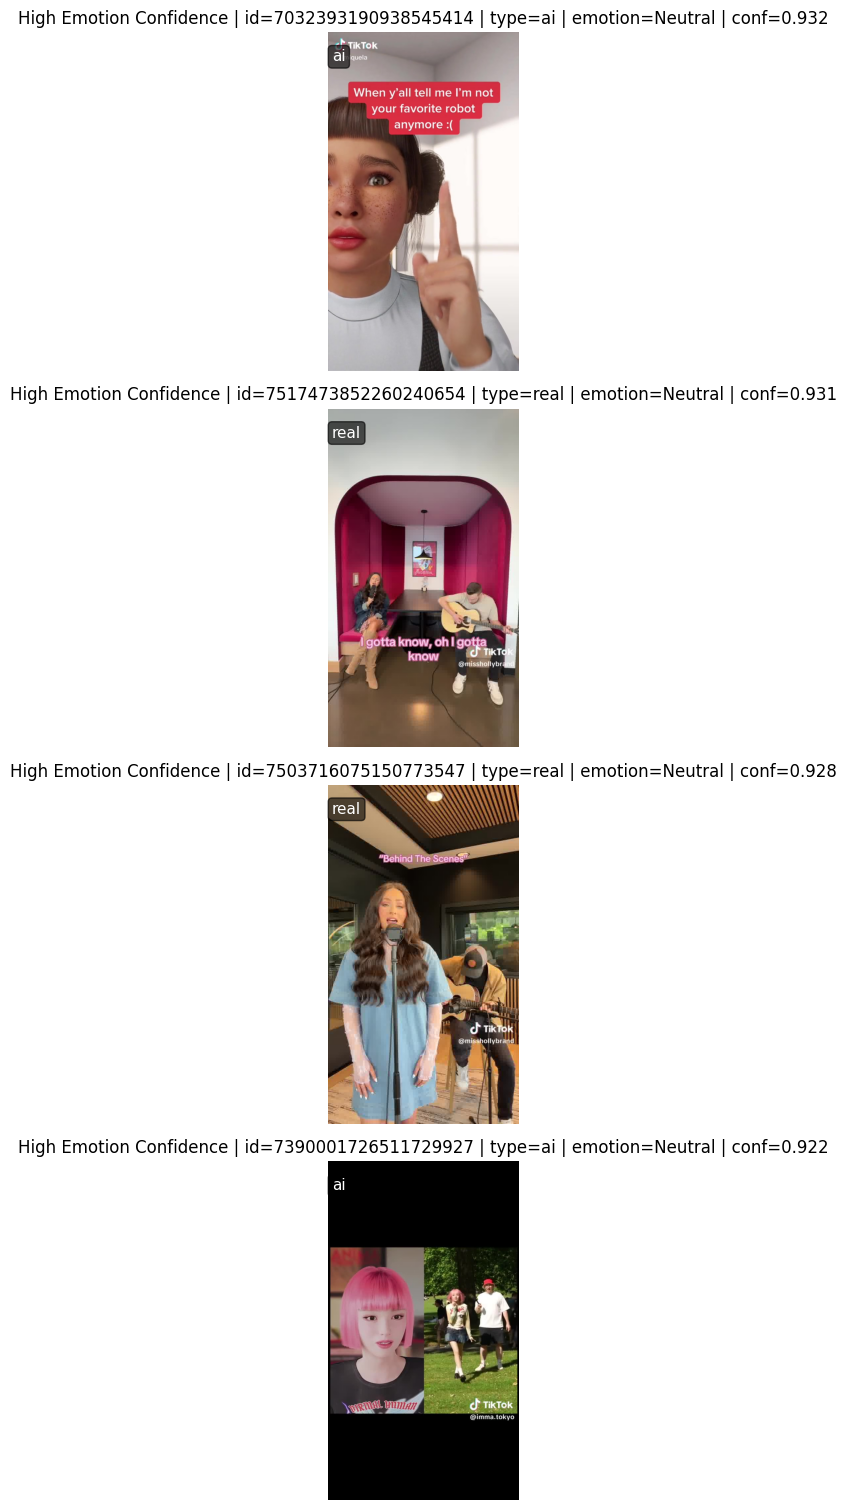

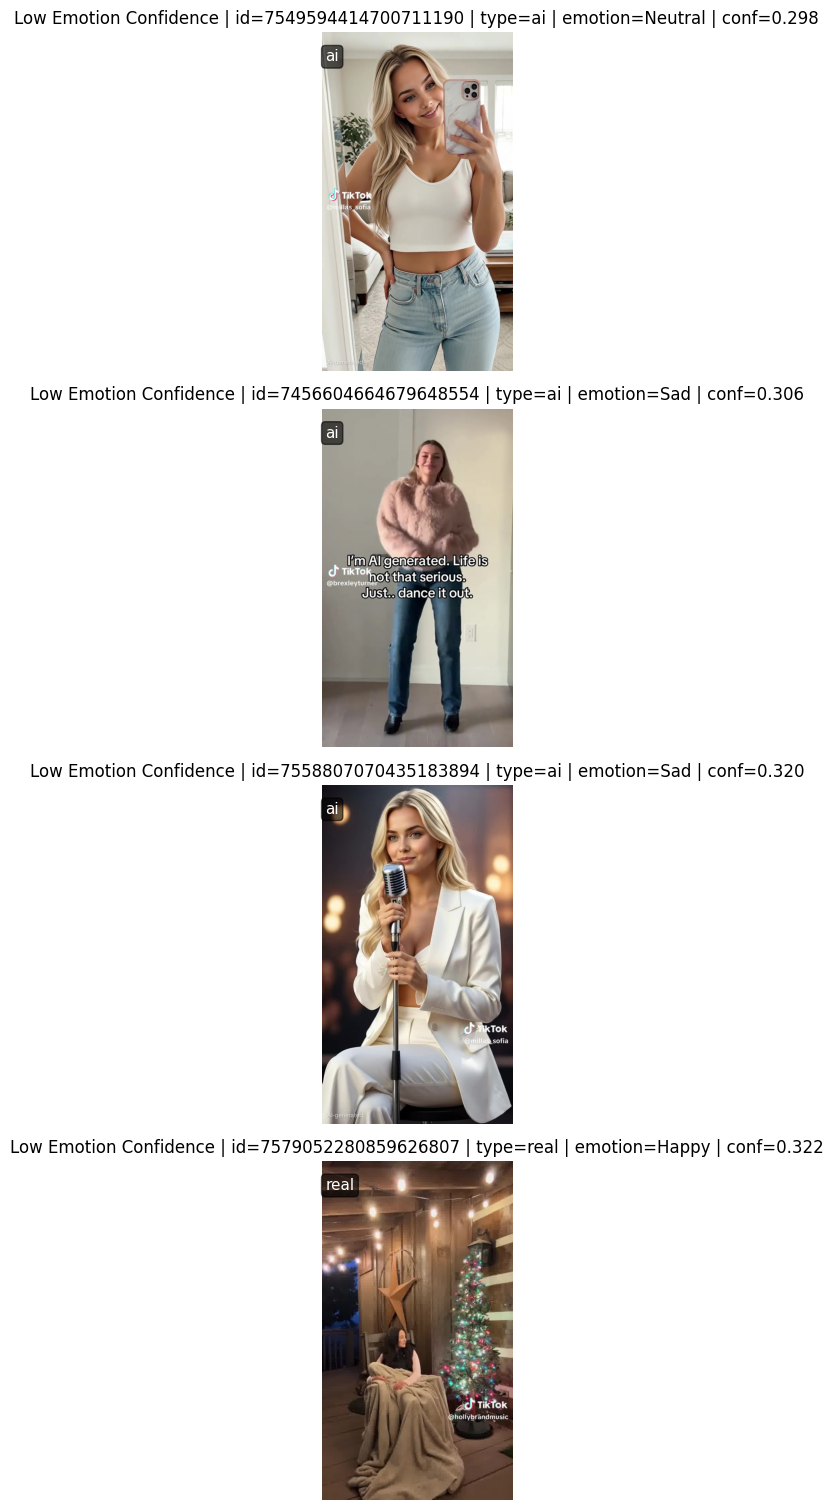

In [5]:
# Beispiele mit hoher und niedriger Emotionskonfidenz
_df = df.dropna(subset=['emotion_major_beit_confidence']).copy()

def pick_examples(df_sorted, n=4):
    rows = []
    for _, row in df_sorted.iterrows():
        vid = get_video_id(row)
        fp = first_frame_path(vid)
        if fp is None:
            continue
        row = row.copy()
        row['frame_path'] = fp
        rows.append(row)
        if len(rows) >= n:
            break
    return rows

def show_examples(rows, title):
    if not rows:
        print(f'No frames found for {title}')
        return

    plt.figure(figsize=(12, 3.8 * len(rows)))
    for i, row in enumerate(rows, 1):
        img = load_image(row['frame_path'])
        ax = plt.subplot(len(rows), 1, i)
        if img is not None:
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.text(0.5, 0.5, 'Image load failed', ha='center', va='center')
            ax.axis('off')

        conf = row['emotion_major_beit_confidence']
        emotion = row.get('emotion_major_beit_readable', '')
        inf = row.get('influencer_type', '')
        vid = get_video_id(row)
        ax.text(0.02, 0.95, f'{inf}', transform=ax.transAxes, ha='left', va='top',
                fontsize=11, color='white',
                bbox=dict(boxstyle='round,pad=0.25', fc='black', alpha=0.6))
        ax.set_title(f'{title} | id={vid} | type={inf} | emotion={emotion} | conf={conf:.3f}')

    plt.tight_layout()
    plt.show()

high_examples = pick_examples(_df.sort_values('emotion_major_beit_confidence', ascending=False), n=4)
low_examples = pick_examples(_df.sort_values('emotion_major_beit_confidence', ascending=True), n=4)

show_examples(high_examples, 'High Emotion Confidence')
show_examples(low_examples, 'Low Emotion Confidence')


In [3]:
summary = df.groupby('influencer_type')[['emotion_major_beit_confidence', 'emotion_unique_labels', 'detected_emotion_frames']].describe().round(4)
display(summary)


emotion_major_beit_confidence                                  \
                                        count    mean     std     min     25%   
influencer_type                                                                 
ai                                      250.0  0.5727  0.1328  0.2980  0.4783   
real                                    250.0  0.5971  0.1311  0.3216  0.5051   

                                        emotion_unique_labels         ...  \
                    50%     75%     max                 count   mean  ...   
influencer_type                                                       ...   
ai               0.5532  0.6620  0.9316                 250.0  2.748  ...   
real             0.5850  0.6819  0.9309                 250.0  3.504  ...   

                           detected_emotion_frames                        \
                  75%  max                   count    mean      std  min   
influencer_type                                                            
ai               3.75  7.0                   250.0  18.564  17.3293  3.0   
real             5.00  7.0                   250.0  43.156  49.0106  5.0   

                                          
                  25%   50%   75%    max  
influencer_type                           
ai                8.0  12.0  19.0  118.0  
real             12.0  25.0  56.0  326.0  

[2 rows x 24 columns]

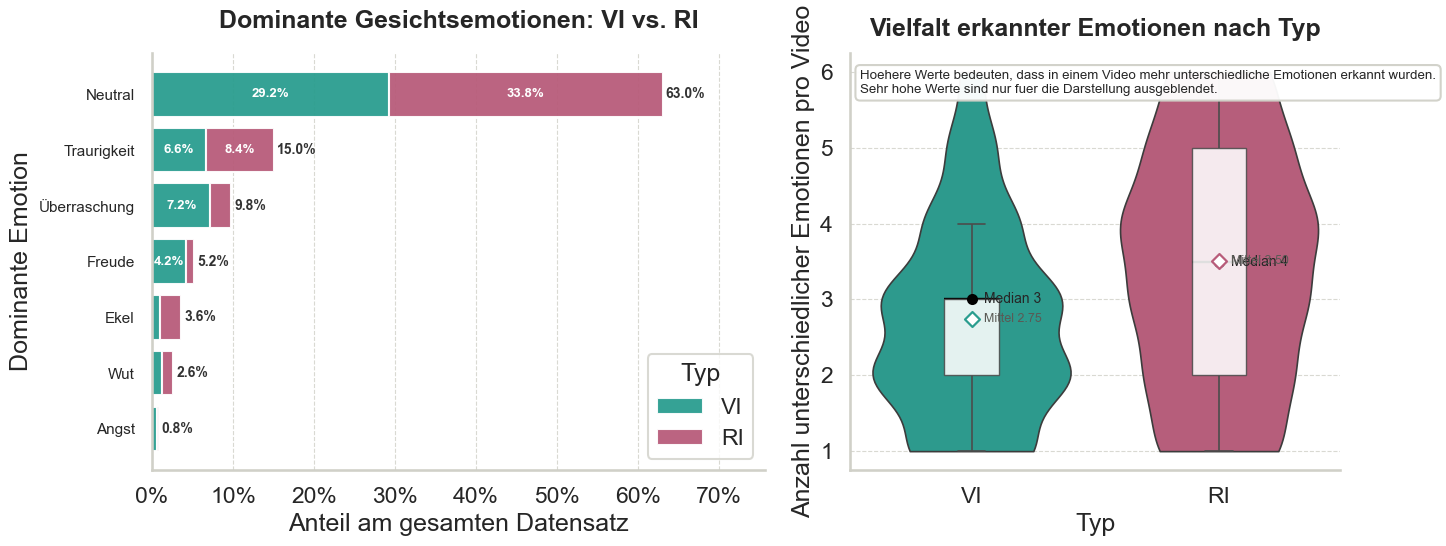

In [4]:
# Visualisierung der Gesichtsemotionen
sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

PALETTE_COLOR = {'VI': '#2A9D8F', 'RI': '#B85C7A'}
ORDER = ['VI', 'RI']
EMOTION_LABEL_MAP_DE = {
    'Angry': 'Wut',
    'Disgust': 'Ekel',
    'Fear': 'Angst',
    'Happy': 'Freude',
    'Neutral': 'Neutral',
    'Sad': 'Traurigkeit',
    'Surprise': 'Überraschung',
}

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'VI', 'real': 'RI'}).fillna(df_plot['influencer_type'])
df_plot['emotion_label_de'] = df_plot['emotion_major_beit_readable'].replace(EMOTION_LABEL_MAP_DE).fillna('Unbestimmt')

# Dominante Emotionskategorien als Anteil am gesamten Datensatz
cat_df = df_plot[['typ', 'emotion_label_de']].dropna().copy()
emotion_counts = (
    cat_df.groupby(['emotion_label_de', 'typ']).size().unstack(fill_value=0).reindex(columns=ORDER, fill_value=0)
)
total_emotion_count = int(emotion_counts[ORDER].to_numpy().sum())
if total_emotion_count == 0:
    raise ValueError('Keine gültigen dominanten Emotionen für VI und RI gefunden.')
emotion_counts['gesamt'] = emotion_counts[ORDER].sum(axis=1)
emotion_counts = emotion_counts.sort_values('gesamt', ascending=True)
emotion_shares = emotion_counts[ORDER].div(total_emotion_count)
emotion_shares['gesamt'] = emotion_shares[ORDER].sum(axis=1)
emotion_order = emotion_shares.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.8), gridspec_kw={'width_ratios': [1.25, 1.0]})

y_pos = np.arange(len(emotion_order))
axes[0].barh(y_pos, emotion_shares['VI'], color=PALETTE_COLOR['VI'], alpha=0.95, label='VI')
axes[0].barh(y_pos, emotion_shares['RI'], left=emotion_shares['VI'], color=PALETTE_COLOR['RI'], alpha=0.95, label='RI')
axes[0].set_title('Dominante Gesichtsemotionen: VI vs. RI', pad=18, weight='semibold')
axes[0].set_xlabel('Anteil am gesamten Datensatz')
axes[0].set_ylabel('Dominante Emotion')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(emotion_order, fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
axes[0].grid(axis='y', visible=False)
axes[0].legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='lower right')
max_emotion_share = float(emotion_shares['gesamt'].max())
axes[0].set_xlim(0, max_emotion_share * 1.20)

for i, (_, row) in enumerate(emotion_shares.iterrows()):
    vi_share = row['VI']
    ri_share = row['RI']
    total_share = row['gesamt']

    if vi_share >= 0.035:
        axes[0].text(vi_share / 2, i, f'{vi_share:.1%}', ha='center', va='center', fontsize=9.5, color='white', weight='semibold')
    if ri_share >= 0.035:
        axes[0].text(vi_share + ri_share / 2, i, f'{ri_share:.1%}', ha='center', va='center', fontsize=9.5, color='white', weight='semibold')

    # Rechts steht der Gesamtanteil der Emotion an allen gültigen Videos.
    axes[0].text(total_share + 0.004, i, f'{total_share:.1%}', ha='left', va='center', fontsize=10, color='#333333', weight='semibold')

metric_df = df_plot[['typ', 'emotion_unique_labels']].dropna().copy()
display_df = metric_df.copy()
if len(display_df) >= 10:
    lower = display_df['emotion_unique_labels'].quantile(0.01)
    upper = display_df['emotion_unique_labels'].quantile(0.95)
    display_df = display_df[display_df['emotion_unique_labels'].between(lower, upper)]

sns.violinplot(
    data=display_df,
    x='typ',
    y='emotion_unique_labels',
    order=ORDER,
    hue='typ',
    dodge=False,
    palette=PALETTE_COLOR,
    inner=None,
    cut=0,
    linewidth=1.2,
    saturation=0.95,
    legend=False,
    ax=axes[1],
)
sns.boxplot(
    data=display_df,
    x='typ',
    y='emotion_unique_labels',
    order=ORDER,
    width=0.22,
    fliersize=0,
    boxprops={'facecolor': 'white', 'alpha': 0.88, 'zorder': 3},
    whiskerprops={'linewidth': 1.2},
    capprops={'linewidth': 1.2},
    medianprops={'color': 'black', 'linewidth': 1.7},
    ax=axes[1],
)
medians = display_df.groupby('typ')['emotion_unique_labels'].median().reindex(ORDER)
means = metric_df.groupby('typ')['emotion_unique_labels'].mean().reindex(ORDER)
for x_pos, grp in zip(range(len(ORDER)), ORDER):
    med_val = medians.get(grp)
    mean_val = means.get(grp)
    if pd.notna(med_val):
        axes[1].scatter(x_pos, med_val, c='black', s=42, zorder=5)
        axes[1].text(x_pos + 0.05, med_val, f'Median {med_val:.0f}', va='center', fontsize=10)
    if pd.notna(mean_val):
        axes[1].scatter(x_pos, mean_val, color='white', edgecolor=PALETTE_COLOR[grp], s=58, linewidth=1.6, marker='D', zorder=5)
        axes[1].text(x_pos + 0.05, mean_val, f'Mittel {mean_val:.2f}', va='center', fontsize=9, color='#5a5a55')
axes[1].set_title('Vielfalt erkannter Emotionen nach Typ', pad=12, weight='semibold')
axes[1].set_xlabel('Typ')
axes[1].set_ylabel('Anzahl unterschiedlicher Emotionen pro Video')
axes[1].text(
    0.02,
    0.96,
    'Höhere Werte bedeuten, dass in einem Video mehr unterschiedliche Emotionen erkannt wurden.\nSehr hohe Werte sind nur für die Darstellung ausgeblendet.',
    transform=axes[1].transAxes,
    ha='left',
    va='top',
    fontsize=9.5,
    bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.96),
)

for ax in np.ravel(axes):
    sns.despine(ax=ax, top=True, right=True)

plt.tight_layout()
plt.show()



In [5]:
# Signifikanztests für Gesichtsemotionen
# - emotion_label (kategorial): Chi²-Test
# - emotion_unique_labels (metrisch): Mann-Whitney-U

chi2_results = []
results = []

label_col = 'emotion_major_beit_readable'
diversity_col = 'emotion_unique_labels'

if label_col in df.columns and 'influencer_type' in df.columns:
    tmp = df[[label_col, 'influencer_type']].dropna().copy()
    if not tmp.empty:
        contingency = pd.crosstab(tmp[label_col], tmp['influencer_type'])
        if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
            chi2, p_val, dof, _ = chi2_contingency(contingency)
            chi2_results.append({'metric': label_col, 'test': 'Chi2', 'chi2': chi2, 'dof': dof, 'p_value': p_val, 'n': len(tmp)})

if diversity_col in df.columns:
    ai_vals = df.loc[df['influencer_type'] == 'ai', diversity_col].dropna()
    real_vals = df.loc[df['influencer_type'] == 'real', diversity_col].dropna()
    if len(ai_vals) > 0 and len(real_vals) > 0:
        u_stat, u_p = mannwhitneyu(ai_vals, real_vals, alternative='two-sided')
        results.append({
            'metric': diversity_col,
            'test': 'Mann-Whitney-U',
            'n_ai': len(ai_vals),
            'n_real': len(real_vals),
            'mean_ai': ai_vals.mean(),
            'mean_real': real_vals.mean(),
            'median_ai': ai_vals.median(),
            'median_real': real_vals.median(),
            'u_stat': u_stat,
            'u_p': u_p,
        })

results_df = pd.DataFrame(results).round(4)
chi2_df = pd.DataFrame(chi2_results).round(4)
display(results_df)
display(chi2_df)



,metric,test,n_ai,n_real,mean_ai,mean_real,median_ai,median_real,u_stat,u_p
0,emotion_major_beit_confidence,Mann-Whitney-U,250,250,0.5727,0.5971,0.5532,0.585,27776.0,0.0315


,metric,test,chi2,dof,p_value,n
0,emotion_major_beit_readable,Chi2,28.0339,6,0.0001,500


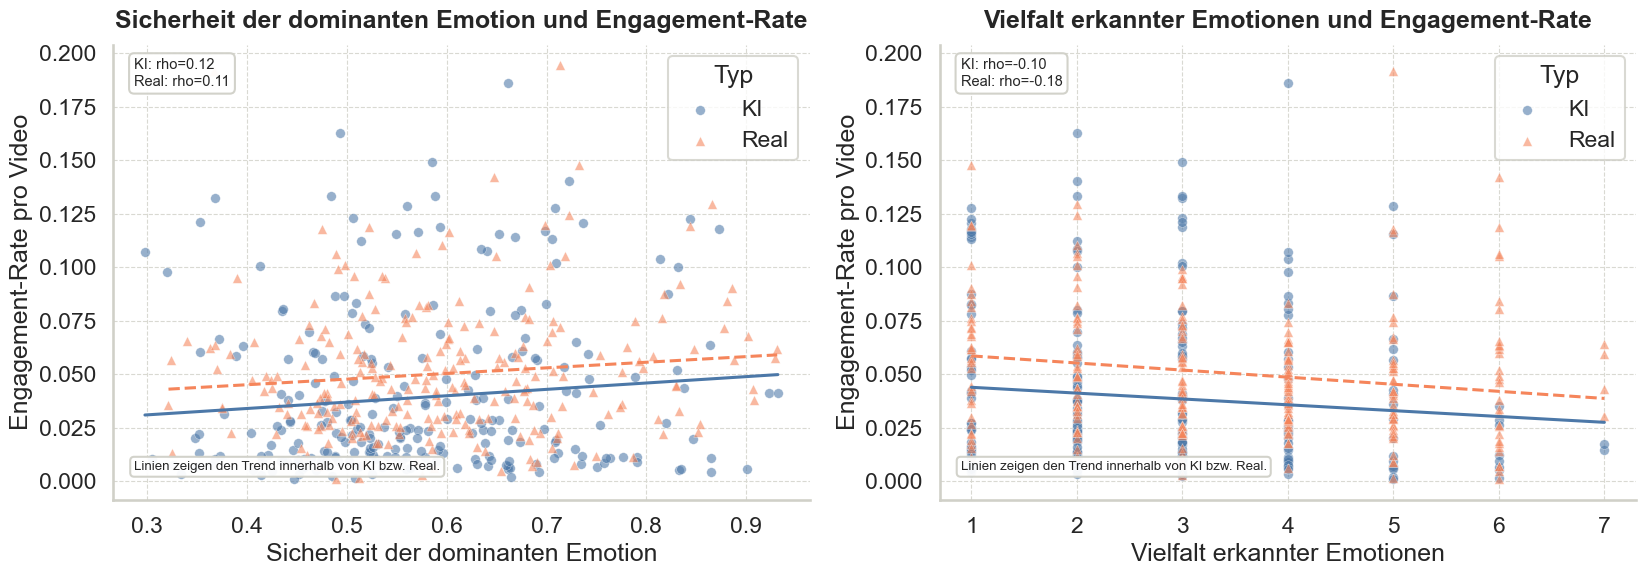

/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_66537/2452939986.py:114: RuntimeWarning: divide by zero encountered in matmul
  y_hat = X_mat @ beta
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_66537/2452939986.py:114: RuntimeWarning: overflow encountered in matmul
  y_hat = X_mat @ beta
/var/folders/xv/tws3wcdj24b6nwt9_f_365jr0000gn/T/ipykernel_66537/2452939986.py:114: RuntimeWarning: invalid value encountered in matmul
  y_hat = X_mat @ beta


,Metrik,Methode,Spearman_rho,p_Wert
0,emotion_major_beit_confidence,Spearman,0.1335,0.0028
1,emotion_unique_labels,Spearman,-0.0662,0.1391


,Metrik,analysis,stat,p_Wert,n,R2,k_dummies
0,emotion_major_beit_readable,ANOVA,2.072,0.055,500,NaN,NaN
1,emotion_major_beit_readable,Dummy-Regression,NaN,NaN,500,0.0246,6.0


In [7]:
# Zusammenhang zwischen Gesichtsemotionen und Engagement-Rate
# - emotion_unique_labels: Spearman
# - emotion_label: ANOVA + Regression mit Dummies

sns.set_theme(
    style='whitegrid',
    context='talk',
    rc={
        'axes.facecolor': 'white',
        'figure.facecolor': 'white',
        'grid.color': '#d9d9d2',
        'grid.linestyle': '--',
        'grid.linewidth': 0.8,
        'axes.edgecolor': '#d0d0c8',
    },
)

PALETTE_COLOR = {'KI': '#4C78A8', 'Real': '#F5855B'}
MARKER = {'KI': 'o', 'Real': '^'}
LINESTYLE = {'KI': '-', 'Real': '--'}

corr_results = []
anova_reg_results = []

df_plot = df.copy()
df_plot['typ'] = df_plot['influencer_type'].map({'ai': 'KI', 'real': 'Real'}).fillna(df_plot['influencer_type'])

if 'video_engagement_rate' in df_plot.columns and 'emotion_unique_labels' in df_plot.columns:
    metric_df = df_plot[['typ', 'emotion_unique_labels', 'video_engagement_rate']].dropna().copy()
    rho_all, p_all = spearmanr(metric_df['emotion_unique_labels'], metric_df['video_engagement_rate'], nan_policy='omit')
    corr_results.append({'Metrik': 'emotion_unique_labels', 'Methode': 'Spearman', 'Spearman_rho': rho_all, 'p_Wert': p_all})

    fig, ax = plt.subplots(figsize=(8.8, 6.1))
    stat_lines = []
    for grp in ['KI', 'Real']:
        sub = metric_df[metric_df['typ'] == grp].copy()
        if sub.empty:
            continue
        rho_grp, p_grp = spearmanr(sub['emotion_unique_labels'], sub['video_engagement_rate'], nan_policy='omit')
        stat_lines.append(f'{grp}: rho={rho_grp:.2f}')
        sns.scatterplot(
            data=sub,
            x='emotion_unique_labels',
            y='video_engagement_rate',
            color=PALETTE_COLOR[grp],
            marker=MARKER[grp],
            edgecolor='white',
            linewidth=0.35,
            s=48,
            alpha=0.58,
            ax=ax,
            label=grp,
        )
        sns.regplot(
            data=sub,
            x='emotion_unique_labels',
            y='video_engagement_rate',
            scatter=False,
            ci=None,
            line_kws={'color': PALETTE_COLOR[grp], 'linewidth': 2.2, 'linestyle': LINESTYLE[grp]},
            ax=ax,
        )

    ax.set_title('Vielfalt erkannter Emotionen und Engagement-Rate', pad=12, weight='semibold')
    ax.set_xlabel('Anzahl unterschiedlicher Emotionen pro Video')
    ax.set_ylabel('Engagement-Rate pro Video')
    ax.text(
        0.03,
        0.97,
        '\n'.join(stat_lines),
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=10.5,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )
    ax.text(
        0.03,
        0.06,
        'Linien zeigen den Trend innerhalb von KI bzw. Real.',
        transform=ax.transAxes,
        ha='left',
        va='bottom',
        fontsize=9.5,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d0d0c8', alpha=0.95),
    )
    ax.legend(title='Typ', frameon=True, facecolor='white', edgecolor='#d0d0c8', loc='best')
    sns.despine(ax=ax, top=True, right=True)
    plt.tight_layout()
    plt.show()

    label_col = 'emotion_major_beit_readable'
    if label_col in df_plot.columns:
        analysis_df = df_plot[[label_col, 'video_engagement_rate']].dropna().copy()
        groups = [g['video_engagement_rate'].values for _, g in analysis_df.groupby(label_col) if len(g) > 1]
        if len(groups) >= 2:
            f_stat, p_val = f_oneway(*groups)
            anova_reg_results.append({'Metrik': label_col, 'analysis': 'ANOVA', 'stat': f_stat, 'p_Wert': p_val, 'n': len(analysis_df)})

        X = pd.get_dummies(analysis_df[label_col], drop_first=True, dtype=float)
        if X.shape[1] > 0:
            X_mat = np.column_stack([np.ones(len(X)), X.values])
            y = analysis_df['video_engagement_rate'].values.astype(float)
            beta, *_ = np.linalg.lstsq(X_mat, y, rcond=None)
            y_hat = X_mat @ beta
            ss_res = np.sum((y - y_hat) ** 2)
            ss_tot = np.sum((y - y.mean()) ** 2)
            r2 = np.nan if ss_tot == 0 else 1 - (ss_res / ss_tot)
            anova_reg_results.append({'Metrik': label_col, 'analysis': 'Dummy-Regression', 'R2': r2, 'n': len(analysis_df), 'k_dummies': X.shape[1]})
else:
    print('video_engagement_rate column not available; skipping correlation/regression analysis.')

corr_df = pd.DataFrame(corr_results).round(4)
anova_reg_df = pd.DataFrame(anova_reg_results).round(4)
display(corr_df)
display(anova_reg_df)



In [8]:
print('Kurzinterpretation:')

def sig_label(p):
    return 'signifikant' if pd.notna(p) and p < 0.05 else 'nicht signifikant'

if 'results_df' in globals() and not results_df.empty:
    row = results_df.iloc[0]
    mean_diff = row['mean_ai'] - row['mean_real']
    direction = 'hoeher bei KI' if mean_diff > 0 else ('hoeher bei Real' if mean_diff < 0 else 'kein Unterschied')
    print(f"- Vielfalt erkannter Emotionen (Mann-Whitney): {sig_label(row['u_p'])} (p={row['u_p']:.4f}). Interpretation: Höhere Werte bedeuten mehr unterschiedliche Emotionen im Video ({direction}).")

if 'chi2_df' in globals() and not chi2_df.empty:
    row = chi2_df.iloc[0]
    print(f"- Dominante Emotionskategorie (Chi²): {sig_label(row['p_value'])} (chi2={row['chi2']:.2f}, p={row['p_value']:.4f}). Interpretation: Die Verteilung der dominanten Emotionen unterscheidet sich zwischen KI und Real.")

if 'corr_df' in globals() and not corr_df.empty:
    row = corr_df.iloc[0]
    rho = row['Spearman_rho']
    p = row['p_Wert']
    direction = 'positiv' if rho > 0 else ('negativ' if rho < 0 else 'neutral')
    print(f"- Engagement ~ Vielfalt erkannter Emotionen (Spearman): {sig_label(p)} (rho={rho:.3f}, p={p:.4f}). Interpretation: {direction}er Zusammenhang mit Engagement.")

if 'anova_reg_df' in globals() and not anova_reg_df.empty:
    for _, row in anova_reg_df.iterrows():
        if row['analysis'] == 'ANOVA':
            print(f"- Engagement ~ dominante Emotionskategorie (ANOVA): {sig_label(row['p_Wert'])} (F={row['stat']:.2f}, p={row['p_Wert']:.4f}).")
        else:
            print(f"- Engagement ~ dominante Emotionskategorie (Dummy-Regression): R²={row['R2']:.3f} (erklaerte Varianz).")



Kurzinterpretation:
- Sicherheit der dominanten Emotion (Mann-Whitney): signifikant (p=0.0315). Interpretation: Höhere Werte deuten auf eine sicherere dominante Emotion hin (höher bei Real).
- Dominante Emotionskategorie (Chi²): signifikant (chi2=28.03, p=0.0001). Interpretation: Die Verteilung der dominanten Emotionen unterscheidet sich zwischen KI und Real.
- Engagement ~ emotion_major_beit_confidence (Spearman): signifikant (rho=0.134, p=0.0028). Interpretation: positiver Zusammenhang mit Engagement.
- Engagement ~ emotion_unique_labels (Spearman): nicht signifikant (rho=-0.066, p=0.1391). Interpretation: negativer Zusammenhang mit Engagement.
- Engagement ~ dominante Emotionskategorie (ANOVA): nicht signifikant (F=2.07, p=0.0550).
- Engagement ~ dominante Emotionskategorie (Dummy-Regression): R²=0.025 (erklaerte Varianz).
